# 📊 Seaborn Practice — Tasks 1 to 8

## About this task notebook

These problems ask you to apply everything from the Seaborn sessions to fresh real-world data. You will load a Gapminder country dataset (countries, life expectancy, GDP, population), the `flights` dataset bundled with Seaborn, and a health-insurance CSV with patient demographics, blood pressure, body-mass index and claim amounts — and you will practise the crucial skill of *matching the right chart to the right question*.

A quick decision guide to keep beside you:

- **Relationship between two numeric columns?** → `sns.scatterplot`. Add `hue` (category → color), `size` (numeric → point size) and `style` (category → marker shape) to carry extra columns.
- **Trend along a continuous axis?** → `sns.lineplot`, which can also show a series per category via `hue`.
- **Distribution shape / density?** → `sns.displot(kind='hist')` for bar histograms (with `col=` faceting and `hue`), `sns.kdeplot` for smooth density — including **bivariate** 2D density when given two columns.
- **Similarity between rows/columns of a table?** → `sns.heatmap(matrix)` for a colored grid, `sns.clustermap(matrix)` when you want the rows/columns grouped by similarity.

Tactical reminders:
- Clean data before plotting: connect, filter (`df.query(...)` or boolean masks), and drop missing values (`dropna()`).
- A two-way condition is just two filters chained: `df[df['age'] < threshold]` then `.query('bmi > ...')`.
- Heatmap and clustermap inputs must be **matrix-shaped** — build them with `pivot_table(...)`, `crosstab(...)` or `.corr()`; numeric column subsets work too as long as missing values are handled.
- Always label your axes and give figures a title before finishing.

Write your answers under each `# code here` cell. There is usually more than one correct solution — a working, readable chart is a good chart.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### `Q-1:` Using Gapminder Data
1. Create a scatter plot of 'gdpPercap' against 'lifeExp' for the year 2007, with the size of the markers determined by 'pop' and the color determined by 'continent'.

## Problem 1 — Gapminder scatter (gdp vs life expectancy)

**Concept.** This is the classic Gapminder plot: every country is one point, the x-axis holds GDP per capita (`gdpPercap`), the y-axis life expectancy (`lifeExp`), and two extra columns ride along as dimensions — `pop` maps to point *size* and `continent` maps to *color* via `hue`. A single scatter then tells a four-variable story about global development.

**Hints.**
- Use Plotly Express to fetch the data: `df = px.data.gapminder()`, then inspect with `df.head()`.
- The chart must show **only the year 2007**, so filter first: `df.query('year == 2007')`.
- `sns.scatterplot(data=df.query('year == 2007'), x='gdpPercap', y='lifeExp', hue='continent', size='pop')` does everything — color by continent, size by population.
- Two useful extras: many countries share small GDPs, so `plt.xscale('log')` spreads them out; `ax.legend(bbox_to_anchor=(1, 1))` keeps the full legend in view.

In [2]:
# code here
import plotly.express as px
df = px.data.gapminder()
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


<Axes: xlabel='gdpPercap', ylabel='lifeExp'>

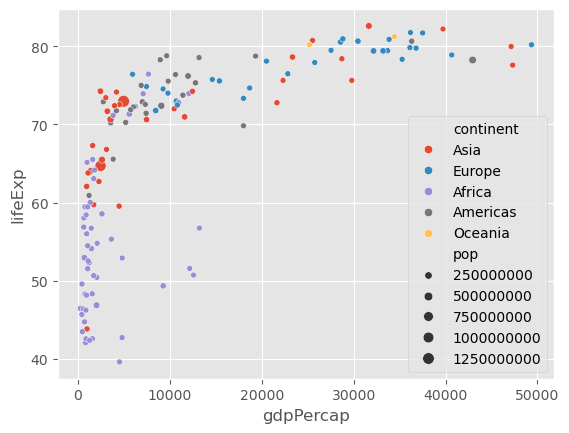

In [3]:
sns.scatterplot(data=df.query('year == 2007'), x='gdpPercap',y='lifeExp',hue='continent',size='pop')

### `Q-2-3:` Using `flights` dataset of seaborn.

2. Using the "flights" dataset that comes with seaborn, create a heatmap that shows the average number of passengers per month for each year.

3. Using the seaborn's flight dataset, create a clustermap to visualize the relationship between the number of passengers, months, and year.


## Problems 2 & 3 — Flights heatmap and clustermap

**Concept.** The `flights` dataset has one row per year-month of the average passengers (columns `year`, `month`, `passengers`). The task is a **two-way table**: months on one axis, years on the other, cell value = mean passengers. That is not a tidy format Plotly can read directly — you must build the matrix first with `df.pivot_table(index='year', columns='month', values='passengers', aggfunc='mean')`. `pivot_table` it returns one column per month, one row per year, so seaborn can color each cell.

**Hints for Problem 2 (heatmap).** `sns.heatmap(pivot, annot=True)` writes numbers in the cells; `cmap='YlOrdB'` is a classic for counts. The yearly trend appears as rows darkening over time.

**Hints for Problem 3 (clustermap).** `sns.clustermap(same_pivot)` re-runs the identical matrix but *hierarchically clusters* the years and months first, then draws dendrograms along the edges. Similar years (e.g. adjacent years with similar seasonal patterns) end up neighbouring, so blocks of similar color emerge — that is the relationship the question asks you to visualize.

In [4]:
# code here
df = sns.load_dataset('flights')
df.tail()

,year,month,passengers
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390
143,1960,Dec,432


C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_1712\403181855.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(df.pivot_table(index='year', columns='month',values='passengers',aggfunc='mean'))


<Axes: xlabel='month', ylabel='year'>

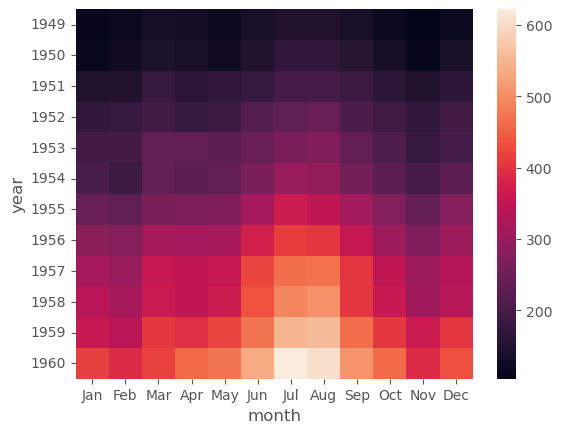

In [5]:
sns.heatmap(df.pivot_table(index='year', columns='month',values='passengers',aggfunc='mean'))

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_1712\838964983.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(df.pivot_table(index='year', columns='month',values='passengers',aggfunc='mean'))


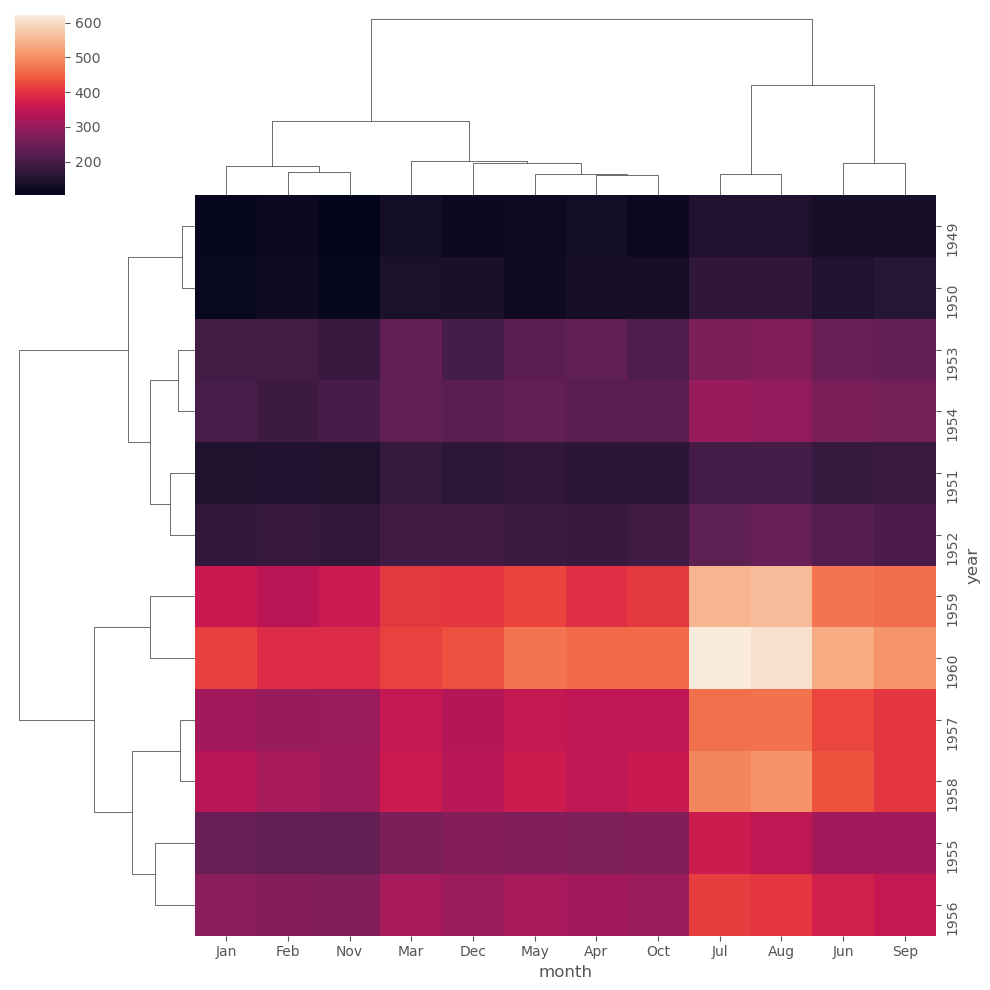

In [6]:
sns.clustermap(df.pivot_table(index='year', columns='month',values='passengers',aggfunc='mean'))

## For questions 4-8:

For these qestions, an insurance dataset is used. You can get details from [here](https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health). And if you want this dataset to use directly, then you can use this link: **https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/pub?gid=220677750&single=true&output=csv**

### **`Q-4:`** Draw a scatter plot based on the below conditions:
1. x-axis should be "age" and y-axis should be "bmi".
2. For hue, size and style parameters use "diabetic", "gender" and "smoker" column respectively.
3. Add title to your chart.
4. Age should be less than 70 percentiles.
5. BMI should be greater than the average value of the filtered age dataset.

## Problem 4 — Insurance scatter: age, BMI, diabetic, claim, smoker

**Concept.** The insurance CSV (read straight from its Google-Sheets URL) has patient columns `age`, `gender`, `bmi`, `bloodpressure`, `diabetic`, `children`, `smoker`, `region` and `claim`. The scatter asks for `age` on x, `bmi` on y, and **three** semantic dimensions: `hue` (diabetic: color), `size` (claim: point size), `style` (smoker: marker shape). It also stacks two defined filters: age below the **70th percentile**, and BMI greater than the average of that already-filtered set.

**Hints.**
- Percentile filter: `temp_df = df[df['age'] < df['age'].quantile(0.70)]`. `quantile(0.70)` computes the 70th percentile directly.
- Second filter on the *result*: `temp_df = temp_df[temp_df['bmi'] > temp_df['bmi'].mean()]` — the mean must come from `temp_df`, not the whole `df` (the statement says "average value of the filtered age dataset").
- A generous canvas first: `plt.subplots(figsize=(12, 8))`.
- `sns.scatterplot(data=temp_df, x='age', y='bmi', hue='diabetic', size='claim', style='smoker')` — every semantic channel maps a column.
- Add axis labels and a title to finish.

In [7]:
# code here
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/pub?gid=220677750&single=true&output=csv')
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [8]:
temp_df = df[df['age'] < df['age'].quantile(0.70)]
temp_df = temp_df[temp_df['bmi'] > temp_df['bmi'].mean()]

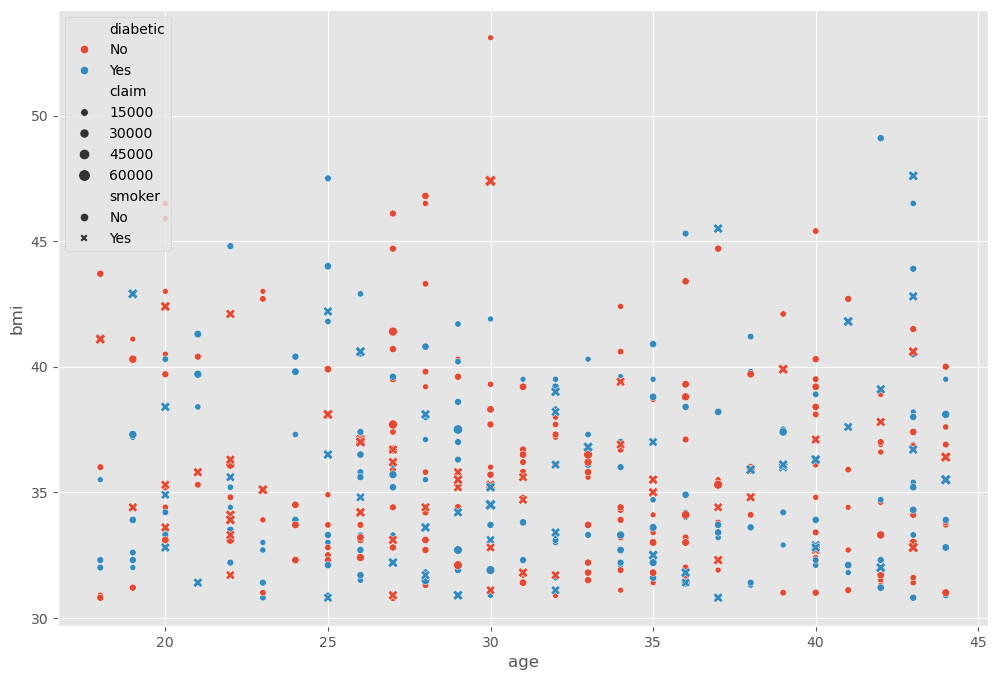

In [9]:
plt.subplots(figsize=(12,8))
sns.scatterplot(data=temp_df, x='age', y='bmi', hue='diabetic',size='claim', style='smoker')
plt.show()

### **`Q-5:`** Draw a line plot by using the below informations

1. bloodpressure vs children
2. Blood-pressure values should be between 90 and 100. The upper and lower limit are included.
3. Show the details of "smoker". 

## Problem 5 — Line plot: bloodpressure vs children, coloured by smoker

**Concept.** A `sns.lineplot` traces one continuous column against another. Here the data must first be **confined to a range** — blood pressure between 90 and 100 (both bounds included). Rather than building a boolean mask by hand, `df.query("bloodpressure >= 90 and bloodpressure <= 100")` does it in one readable line. `hue='smoker'` then draws a separate line (with a confidence band) for smokers and non-smokers, so you can see whether having children shifts blood pressure differently for the two groups.

**Hints.**
- `sns.lineplot(data=df.query("bloodpressure >= 90 and bloodpressure <= 100"), x='bloodpressure', y='children', hue='smoker', err_style=None)` — `err_style=None` suppresses the shaded uncertainty band so the two lines stay clean.
- Axis labels and a title complete the figure.

<Axes: xlabel='bloodpressure', ylabel='children'>

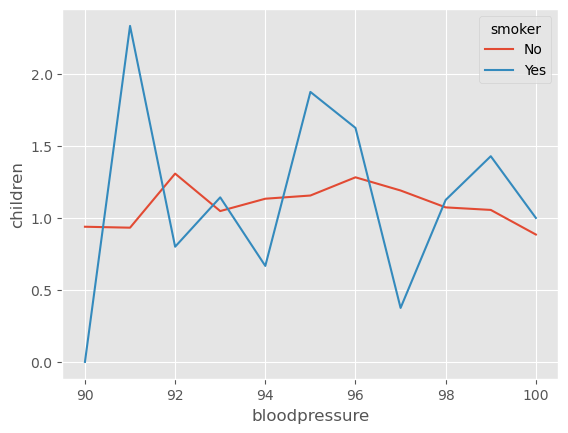

In [10]:
# Code here
sns.lineplot(data = df.query("bloodpressure >= 90 and bloodpressure <= 100"), x='bloodpressure', y='children',hue='smoker',err_style=None)

### **`Q-6:`** Draw a histogram using displot

- based on "age" column.
- Show details of "smoker" (hue).
- Create 2 separate charts for the above 2 conditions based on "gender" side-by-side.

## Problem 6 — Histogram of age by smoker, faceted by gender

**Concept.** `sns.displot(kind='hist', ...)` is the figure-level histogram: bars over intervals of a single numeric column (`age`). Because it is figure-level, it supports both `hue` — overlay the distribution for smokers and non-smokers with different colors — and `col`, which **splits the data into separate panels** per category. `col='gender'` therefore answers *"show the age distribution of smokers vs non-smokers, side by side for males and females"*.

**Hints.**
- `sns.displot(data=df, x='age', hue='smoker', kind='hist', col='gender')` produces one histogram panel per gender, each with two colored bars per bin.
- The faceted panels share the same y-scale, so the two genders are directly comparable.

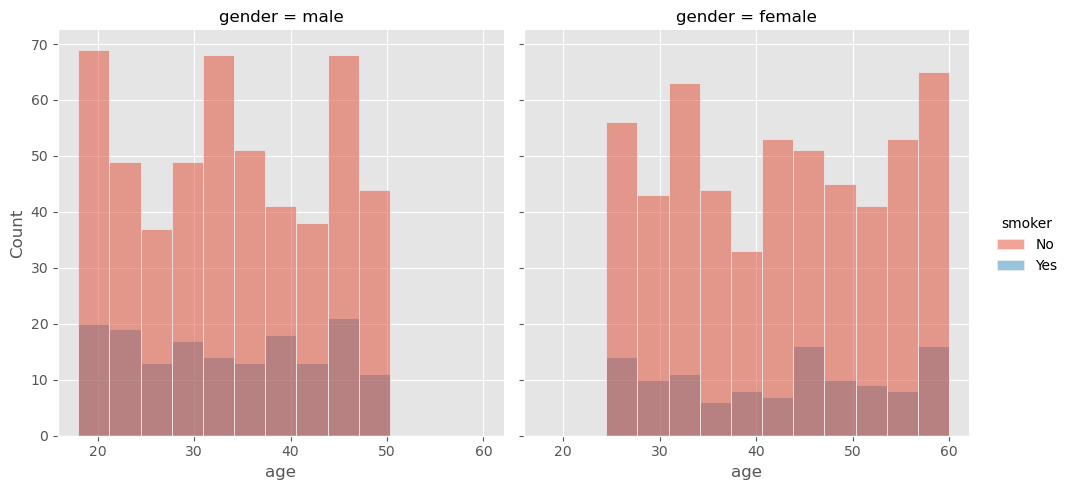

In [11]:
# code here
sns.displot(data=df,x='age',hue='smoker',kind='hist', col='gender')

### **`Q-7:`** Draw a kde plot between "age" and "bloodpressure".

## Problem 7 — Bivariate KDE: bloodpressure vs age

**Concept.** `sns.kdeplot` given **two** columns becomes a 2D density estimate: instead of one curve, seaborn overlays horizontal kernels at each observation, producing filled contour-like bands. Each band bounds a region of high density — the darkest center is the most common combination of `bloodpressure` and `age`. This is a bivariate distribution plot and is the right choice when you want to see *where* on the bloodpressure(age) plane values cluster.

**Hints.**
- `sns.kdeplot(data=df, x='bloodpressure', y='age')` — no hue needed; the intensity is encoded by the contour color.
- Compare with the histogram from Problem 6: the KDE smooths rather than bins, and it shows the joint behavior of two variables at once.

<Axes: xlabel='bloodpressure', ylabel='age'>

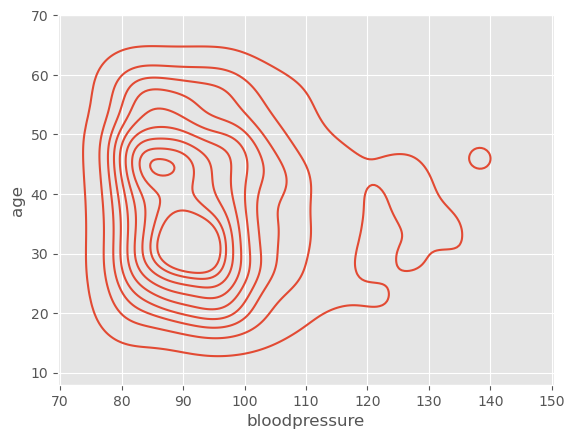

In [12]:
# code here
sns.kdeplot(data=df,x='bloodpressure',y='age')

### **`Q-8:`** Draw a clustermap between between "age", "bmi" and "bloodpressure".

## Problem 8 — Clustermap of age, bmi, bloodpressure

**Concept.** A `clustermap` needs a 2D matrix. Here the "matrix" is simply the numeric columns themselves — every patient row carries `age`, `bmi` and `bloodpressure`. Feeding the three columns straight in produces a figure with patients as rows and the three features as columns; the clustering then groups **similar patients** (rows) by their measurement profile. Because the columns are only three, there is not enough data to cluster them meaningfully, so the interesting structure is the row ordering by the dendrogram.

**Hints.**
- The dataset contains `NaN`s — seaborn cannot cluster missing values, so `.dropna()` must remove those rows first: `sns.clustermap(df[['age', 'bmi', 'bloodpressure']].dropna())`.
- Run `df.isnull().sum()` and `df.shape` afterwards to confirm the cleaned size (1340 → fewer after dropping the ~8 NaN rows). Clustermaps of raw observation frames are a quick way to spot outlier rows as dark or light streaks.

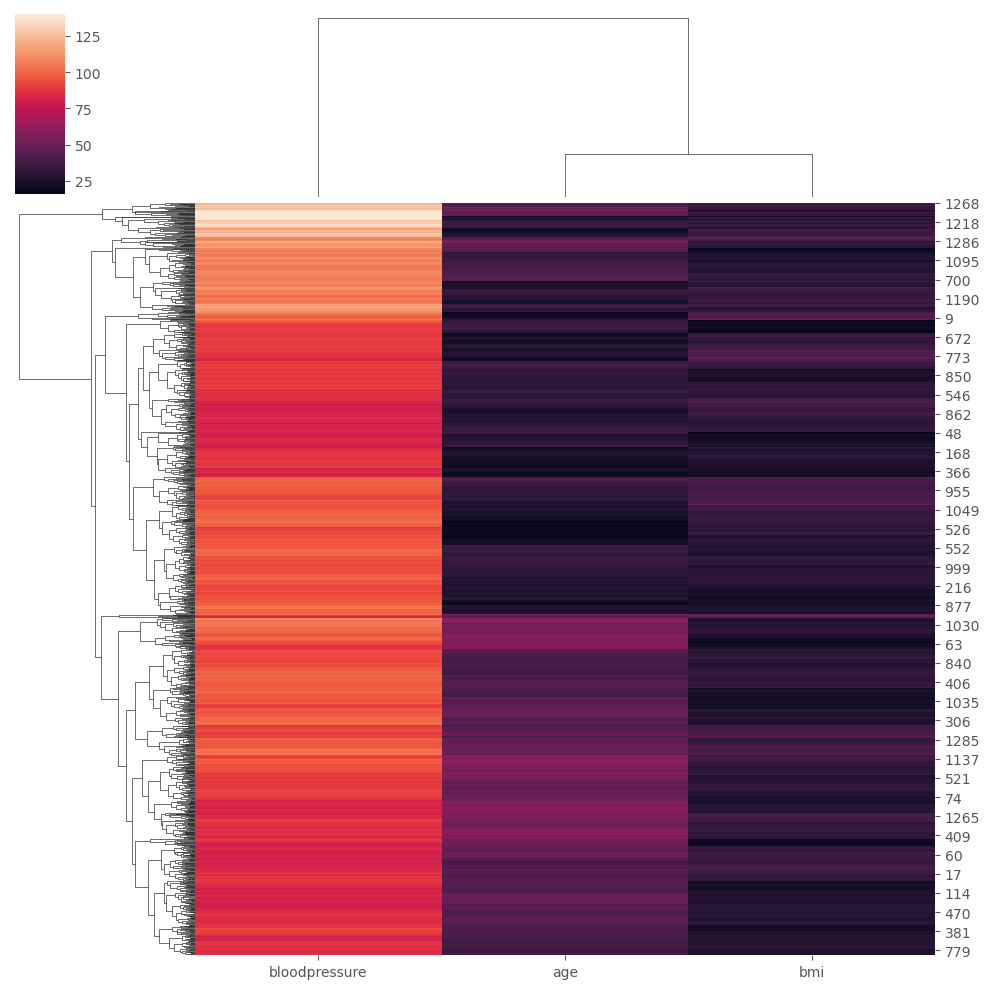

In [13]:
# code here

sns.clustermap(df[['age','bmi','bloodpressure']].dropna())

In [14]:
df.isnull().sum()

index            0
PatientID        0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [15]:
df.shape

(1340, 11)

## Summary

In this task notebook you turned questions into Seaborn plots. For relationships you built a four-variable Gapminder scatter (`hue`, `size`, a `year == 2007` filter and a log axis) and an insurance scatter with three semantic channels (`hue`/`size`/`style`) on data filtered by percentile and mean. For two-way tables you mastered `pivot_table(index='year', columns='month', values='passengers', aggfunc='mean')` feeding both `heatmap` and `clustermap`, and used `clustermap` on raw numeric patient columns after `dropna()`. You applied `lineplot` with a range filter and `hue`, `displot(kind='hist', col='gender')` with `hue` for faceted comparison, and a bivariate `kdeplot` for joint density. The recurring lessons: filter and reshape before you plot, `hue`/`size`/`style`/`col` turn a flat chart into a multi-dimensional one, and every figure gets axis labels and a title.